## Homework 7: Clustering & PCA with High-Dimensional Data
Objective:
To determine if K-Means or DBSCAN can accurately breast cancer patients into meaningful clusters and to evaluate the impact of PCA on high-dimensional clustering.
### Part 1: Initial Clustering 
Load the dataset (from sklearn.datasets import load_breast_cancer

data = load_breast_cancer )

drop the "target" column (Diagnosis). You should only have the 30 numerical features.
Standardization: Apply StandardScaler. This is mandatory as features have vastly different scales. Then Cluster the data using k-means and DBSCAN algorithm.
 - K-Means: Use the Elbow Method to suggest an optimal K, But if not 2, use K=2
 - DBSCAN: Attempt to find an appropriate eps and min_samples.
 - Metrics: Calculate the Silhouette Score for both
 
### Part 2: Dimensionality Reduction (PCA)
    - Perform PCA: Run PCA on your scaled 30-feature data.
    - Variance Analysis: Plot the Cumulative Explained Variance ratio.
    - Identify the minimum number of Principal Components (PCs) needed to capture ~85% of the variance.
    - Interpretation: Plot the heatmap of loading. Also identify which 3 original features contribute the most to Principal Component 1?
    
### Part 3: Clustering Using Principal Components
    - Reduce your dataset to the number of PCs identified in Part 2.
    - Run K-Means (K=2) on the PCA-transformed data.
    - Run DBSCAN on the PCA-transformed data.
    - Metric Comparison: Compare the Silhouette Score of the PCA-based clusters against the 30-feature clusters from Part 1.
    
   
### Part 4: Visual Validation
    - Scatter Plot: Create a 2D plot using PC1 and PC2, Color the points using your K-Means labels (If your Kmeans .
    - Create a second version of the plot colored by the original labels (target).
    - How closely did the unsupervised K-Means clusters match the actual medical diagnosis? 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Part 1 Responses:

In [2]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

data_scaled = StandardScaler().fit_transform(data.data)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

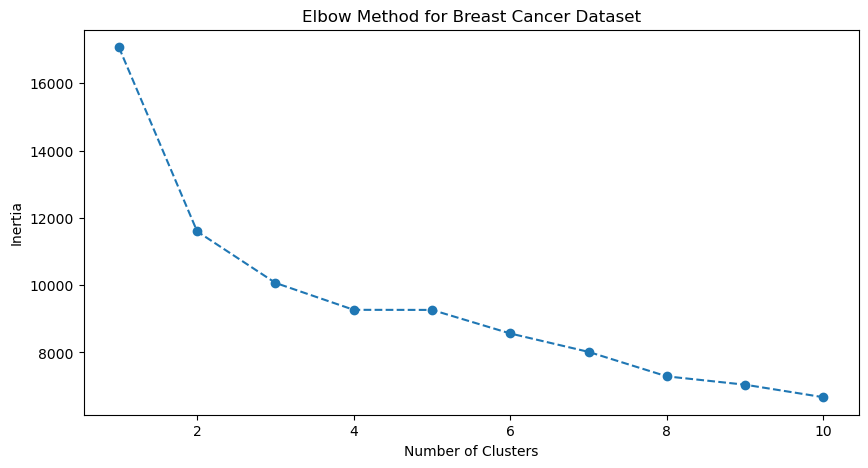

In [16]:
inertia =  []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

kmeans = KMeans(n_clusters=k, random_state=42)
K_label = kmeans.fit_predict(data_scaled)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Breast Cancer Dataset')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [4]:
db_data = DBSCAN(eps=2.5, min_samples=5).fit(data_scaled)
DBSCAN_label = db_data.fit_predict(data_scaled)


In [5]:
kmean_sil = silhouette_score(data_scaled, K_label)
dbscan_sil = silhouette_score(data_scaled, DBSCAN_label)

print("KMean Silhouette Score:", kmean_sil)
print("DBSCAN Silhouette Score:", dbscan_sil)

KMean Silhouette Score: 0.14706722381698445
DBSCAN Silhouette Score: -0.016791147519226227


## Part 2 Responses:

In [6]:
pca = PCA()
score = pca.fit_transform(data_scaled)
pca_df = pd.DataFrame(data=score[:,:2], columns=['PC1', 'PC2'])
features = df.columns

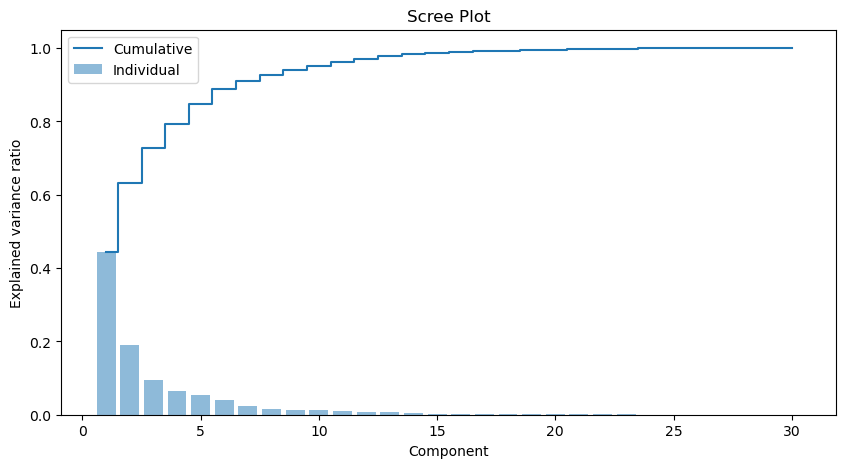

In [7]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.5, label='Individual')
plt.step(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), where='mid', label='Cumulative')
plt.ylabel('Explained variance ratio'); plt.xlabel('Component'); plt.title('Scree Plot'); plt.legend(); plt.show()

In [8]:
PCs_85 = np.argmax(cumulative_variance >= 0.85) + 1
print(PCs_85)

6


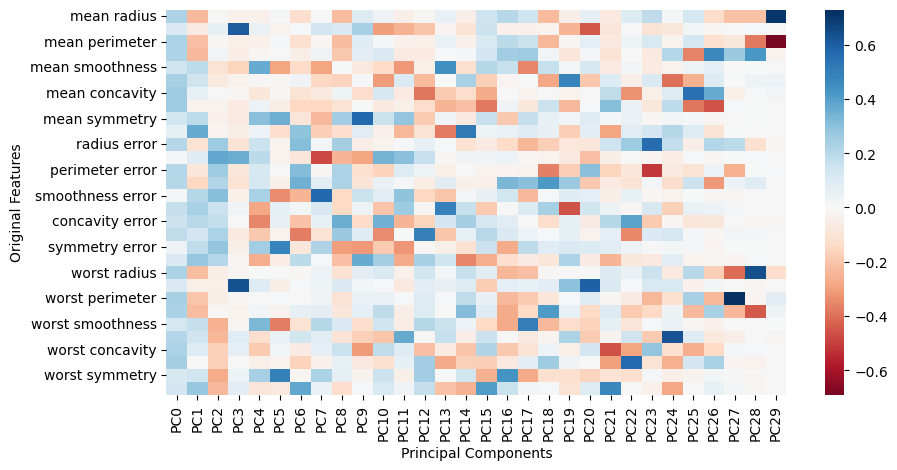

mean fractal dimension     0.366575
fractal dimension error    0.280092
worst fractal dimension    0.275339
Name: PC1, dtype: float64

In [9]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i}' for i in range(pca.n_components_)],
    index=features
)

plt.figure(figsize=(10, 5))
sns.heatmap(loadings, cmap = 'RdBu', center=0)
plt.ylabel('Original Features')
plt.xlabel('Principal Components')
plt.show()

# For the top 3 PCs, instead of the green/red plot
loadings['PC1'].abs().sort_values(ascending=False).head(3)

## Part 3 Responses:

In [10]:
PCA_reduced = PCA(n_components=PCs_85)
PCA_scaled_reduced = PCA_reduced.fit_transform(data_scaled)

In [11]:
kmeans_new_pca = KMeans(n_clusters = 2, random_state = 42)
kmeans_new_labels = kmeans_new_pca.fit_predict(PCA_scaled_reduced)
kmeans_new_sil = silhouette_score(PCA_scaled_reduced, kmeans_new_labels)

In [12]:
DBSCAN_PCA = DBSCAN(eps=2.5, min_samples = 5)
DBSCAN_label_PCA = DBSCAN_PCA.fit_predict(PCA_scaled_reduced)
DBSCAN_PCA_sil = silhouette_score(PCA_scaled_reduced, DBSCAN_label_PCA)

In [13]:
print("PCA KMean", kmeans_new_sil)
print("PCA DBSCAN", DBSCAN_PCA_sil)

PCA KMean 0.377484304321923
PCA DBSCAN 0.3574463825737113


The PCA significantly improved the silhouette score compared to the regular features. The PCA for the DBSCAN overwhelmingly changed for the better, meaning the clustering is better with the PCA than the regular features. The KMean also improved, but not as significantly.

## Part 4 Responses

In [14]:
def draw_biplot(score, coeff, labels=None):
    xs = score[:,0]
    ys = score[:,1]
    
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())
    
    plt.figure(figsize=(10, 5))
    
    plt.scatter(xs * scalex, ys * scaley, alpha=0.3, c='yellow')
    
    for i in range(coeff.shape[0]):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1], 
                  color='red', alpha=0.7, head_width=0.02)
        
        if labels is not None:
            plt.text(coeff[i,0] * 1.20, coeff[i,1] * 1.20, 
                     labels[i], color='green', 
                     ha='center', va='center')

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCPlot, Arrows = Features")
    plt.axhline(0, color='black', lw=1, alpha=0.5)
    plt.axvline(0, color='black', lw=1, alpha=0.5)
    plt.grid(alpha=0.3)
    plt.show()

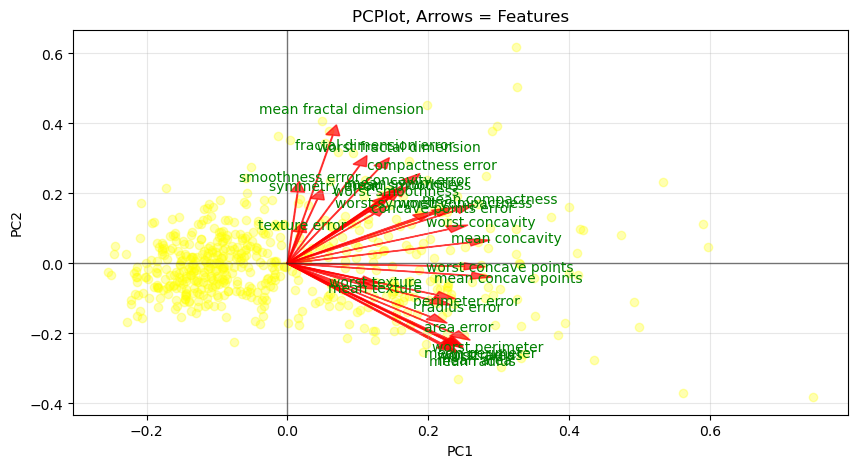

In [15]:
draw_biplot(score,pca.components_.T, labels=features)

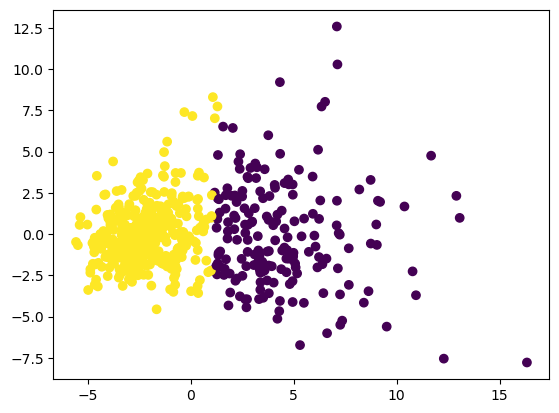

In [24]:
plt.scatter(pca_df['PC1'], pca_df['PC2'], c = kmeans_new_labels)

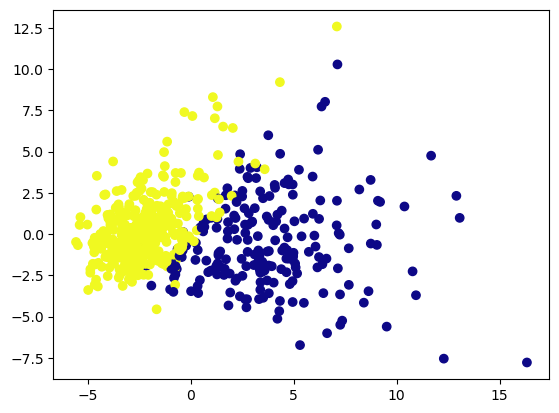

In [25]:
plt.scatter(pca_df['PC1'], pca_df['PC2'], c = data.target, cmap = 'plasma')